# Exploratory Data Analysis: `FareedKhan/1k_stories_100_genre`

This notebook profiles the dataset used for the take-home assessment and pulls out what the three tasks need:

| Task | What it needs from the data |
|---|---|
| 1. Story retrieval chatbot | Unique ids, clean titles and genres for exact lookup; story lengths in tokens (chunking and context size); how well lexical retrieval already works |
| 2. 100-genre classifier (must not degrade the chatbot) | Class balance, samples per class, label noise, how separable genres are, which genres get confused |
| 3. CPU deployment | Corpus size, number of chunks, index size, prompt lengths that drive latency |

Every number in the **Key findings** cell at the end is computed from the data, so the notebook stays correct if it is re-run.

## 0. Setup

In [1]:
# !pip install -q datasets pandas numpy matplotlib seaborn scikit-learn transformers
import re, math, warnings, collections, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RNG = 42
FINDINGS = {}   # collected along the way, printed at the end

In [2]:
import os
LOCAL_PATH = os.environ.get("STORIES_LOCAL_PATH")  # optional: a local .parquet/.csv/.jsonl copy

if LOCAL_PATH:
    ext = LOCAL_PATH.rsplit(".", 1)[-1]
    df = {"parquet": pd.read_parquet, "csv": pd.read_csv,
          "jsonl": lambda p: pd.read_json(p, lines=True), "json": pd.read_json}[ext](LOCAL_PATH)
    splits = {"train": len(df)}
else:
    from datasets import load_dataset
    ds = load_dataset("FareedKhan/1k_stories_100_genre")
    splits = {k: len(v) for k, v in ds.items()}
    df = pd.concat([v.to_pandas().assign(_split=k) for k, v in ds.items()], ignore_index=True)

print("Splits:", splits)
print("Shape:", df.shape)
df.head()

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Splits: {'train': 1000}
Shape: (1000, 5)


,id,title,story,genre,_split
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant strides in space exploration and interstellar travel. The United Earth ...",Science Fiction,train
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone brighter and the grass was greener, there existed a magical forest known as ...",Fantasy,train
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town called Whispering Shadows, life seemed to move at a peaceful pace. The t...",Mystery,train
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small village nestled in the heart of the English countryside, far from the ...",Historical Adventure,train
4,513427,The Shadows of St. Augustine,"In the sun-drenched coastal city of St. Augustine, Florida, a group of five friends found themselves entangled in a ...",Thriller,train


## 1. Schema, missing values and ids

In [3]:
display(df.dtypes.to_frame("dtype"))
text_cols = [c for c in ["story", "genre", "title", "id"] if c in df.columns]
missing = pd.DataFrame({
    "null": df[text_cols].isna().sum(),
    "empty/whitespace": df[text_cols].astype(str).apply(lambda s: s.str.strip().eq("").sum()),
})
display(missing)
FINDINGS["n_rows"] = len(df)
FINDINGS["missing_cells"] = int(missing.values.sum())

,dtype
id,int64
title,object
story,object
genre,object
_split,object


,null,empty/whitespace
story,0,0
genre,0,0
title,0,0
id,0,0


In [4]:
ids = df["id"].astype(str)
FINDINGS["ids_unique"] = ids.is_unique
FINDINGS["id_dupes"] = int(ids.duplicated().sum())
print("ids unique:", ids.is_unique, "| duplicated ids:", FINDINGS["id_dupes"])
print("id dtype:", df["id"].dtype, "| examples:", ids.head(5).tolist())
id_len = ids.str.len()
print("id length min/max:", id_len.min(), id_len.max())
print("id charset:", "".join(sorted(set("".join(ids)))))
# Are ids sequential integers? (matters for 'show me story 42'-style lookups)
num = pd.to_numeric(ids, errors="coerce")
if num.notna().all():
    s = num.sort_values().astype(int)
    print("numeric ids, range", s.min(), "to", s.max(), "| contiguous:", (s.diff().dropna() == 1).all())
    FINDINGS["id_format"] = f"numeric {s.min()}-{s.max()}"
else:
    FINDINGS["id_format"] = f"string, length {id_len.min()}-{id_len.max()}"

ids unique: True | duplicated ids: 0
id dtype: int64 | examples: ['457580', '297904', '620436', '634687', '513427']
id length min/max: 4 6
id charset: 0123456789
numeric ids, range 1328 to 998783 | contiguous: False


## 2. Genres: balance and label hygiene

99 genres | stories per genre: min=10, median=10.0, max=20
Imbalance ratio (max/min): 2.0 | normalized entropy (1 = perfectly balanced): 0.9992


,count,mean,std,min,25%,50%,75%,max
stories per genre,99.0,10.10101,1.005038,10.0,10.0,10.0,10.0,20.0


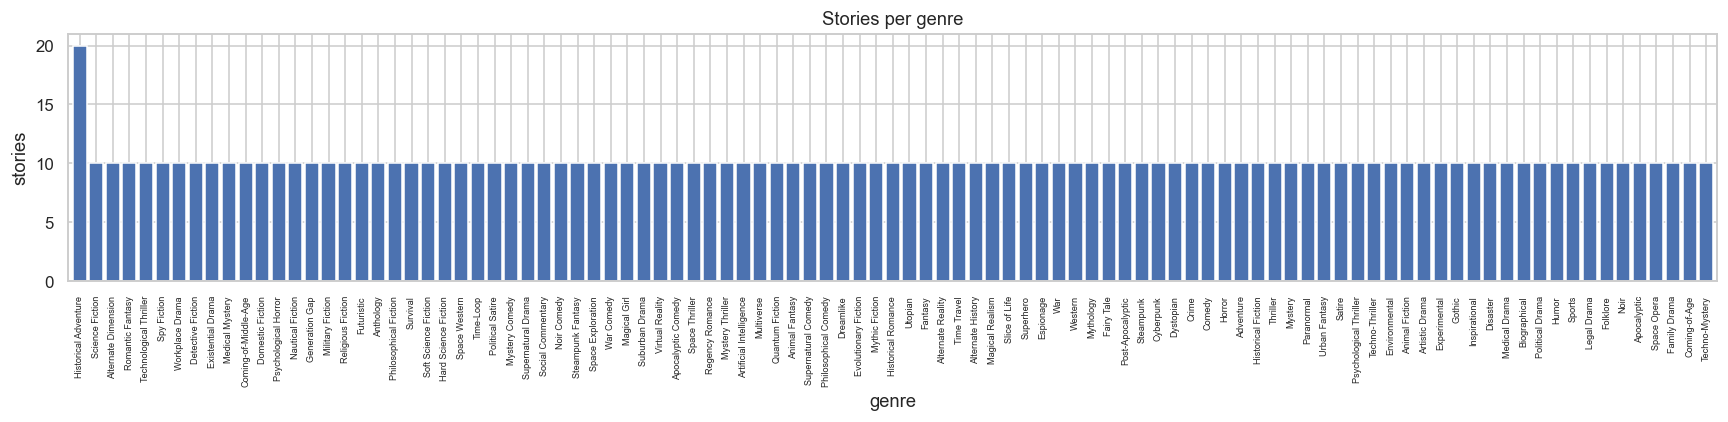

In [5]:
g = df["genre"].astype(str)
counts = g.value_counts()
FINDINGS["n_genres"] = counts.size
FINDINGS["per_genre_min"], FINDINGS["per_genre_max"] = int(counts.min()), int(counts.max())
FINDINGS["imbalance_ratio"] = round(counts.max() / counts.min(), 2)
p = counts / counts.sum()
FINDINGS["norm_entropy"] = round(float(-(p * np.log(p)).sum() / np.log(len(p))), 4)

print(f"{counts.size} genres | stories per genre: min={counts.min()}, median={counts.median()}, max={counts.max()}")
print("Imbalance ratio (max/min):", FINDINGS["imbalance_ratio"], "| normalized entropy (1 = perfectly balanced):", FINDINGS["norm_entropy"])
display(counts.describe().to_frame("stories per genre").T)

fig, ax = plt.subplots(figsize=(16, 4))
counts.plot.bar(ax=ax, color="#4C72B0", width=0.85)
ax.set_title("Stories per genre"); ax.set_ylabel("stories"); ax.tick_params(axis="x", labelsize=6)
plt.tight_layout(); plt.show()

In [6]:
# Label hygiene: variants that differ only by case/whitespace/punctuation would silently split a class.
norm = lambda s: re.sub(r"[^a-z0-9]+", " ", s.lower()).strip()
gn = pd.Series(counts.index).map(norm)
collide = gn[gn.duplicated(keep=False)]
FINDINGS["genre_name_collisions"] = int(collide.nunique())
print("Genre names colliding after normalization:", collide.nunique())
if len(collide):
    display(pd.DataFrame({"raw": counts.index[collide.index], "normalized": collide}))

# Which genre names look alike (shared words, e.g. 'Space Opera' vs 'Space Western')?
from difflib import SequenceMatcher
names = list(counts.index)
pairs = sorted(((SequenceMatcher(None, a.lower(), b.lower()).ratio(), a, b)
                for i, a in enumerate(names) for b in names[i+1:]), reverse=True)[:15]
display(pd.DataFrame(pairs, columns=["name_similarity", "genre_a", "genre_b"]).round(3))
print("All genres:\n", ", ".join(sorted(names)))

Genre names colliding after normalization: 0


,name_similarity,genre_a,genre_b
0,0.864,Technological Thriller,Psychological Thriller
1,0.857,Science Fiction,Soft Science Fiction
2,0.857,Science Fiction,Hard Science Fiction
3,0.815,Post-Apocalyptic,Apocalyptic
4,0.810,Psychological Horror,Psychological Thriller
5,0.800,Soft Science Fiction,Hard Science Fiction
6,0.800,Nautical Fiction,Animal Fiction
7,0.800,Domestic Fiction,Mythic Fiction
8,0.788,Coming-of-Middle-Age,Coming-of-Age
9,0.780,Philosophical Fiction,Philosophical Comedy


All genres:
 Adventure, Alternate Dimension, Alternate History, Alternate Reality, Animal Fantasy, Animal Fiction, Anthology, Apocalyptic, Apocalyptic Comedy, Artificial Intelligence, Artistic Drama, Biographical, Comedy, Coming-of-Age, Coming-of-Middle-Age, Crime, Cyberpunk, Detective Fiction, Disaster, Domestic Fiction, Dreamlike, Dystopian, Environmental, Espionage, Evolutionary Fiction, Existential Drama, Experimental, Fairy Tale, Family Drama, Fantasy, Folklore, Futuristic, Generation Gap, Gothic, Hard Science Fiction, Historical Adventure, Historical Fiction, Historical Romance, Horror, Humor, Inspirational, Legal Drama, Magical Girl, Magical Realism, Medical Drama, Medical Mystery, Military Fiction, Multiverse, Mystery, Mystery Comedy, Mystery Thriller, Mythic Fiction, Mythology, Nautical Fiction, Noir, Noir Comedy, Paranormal, Philosophical Comedy, Philosophical Fiction, Political Drama, Political Satire, Post-Apocalyptic, Psychological Horror, Psychological Thriller, Quantum F

## 3. Titles: uniqueness and usefulness as lookup keys

In [7]:
t = df["title"].astype(str)
tn = t.map(norm)
FINDINGS["title_exact_dupes"] = int(t.duplicated(keep=False).sum())
FINDINGS["title_norm_dupes"] = int(tn.duplicated(keep=False).sum())
FINDINGS["unique_titles"] = int(t.nunique())
print(f"unique titles: {t.nunique()} / {len(t)}")
print("rows sharing an exact title:", FINDINGS["title_exact_dupes"])
print("rows sharing a normalized title (case/punct-insensitive):", FINDINGS["title_norm_dupes"])

dup_titles = df[tn.duplicated(keep=False)].assign(_t=tn).sort_values("_t")
display(dup_titles[["id", "title", "genre"]].head(30))
# Do duplicated titles cross genres? Then 'give me <title>' is ambiguous and the bot must disambiguate.
cross = dup_titles.groupby("_t")["genre"].nunique()
FINDINGS["dup_titles_cross_genre"] = int((cross > 1).sum())
print("duplicated titles that span more than one genre:", FINDINGS["dup_titles_cross_genre"])

unique titles: 1000 / 1000
rows sharing an exact title: 0
rows sharing a normalized title (case/punct-insensitive): 6


,id,title,genre
271,36632,Operation Nightfall,Spy Fiction
471,675515,Operation: Nightfall,Spy Fiction
403,320505,The Chronicles of the Lost Kingdom,Historical Adventure
703,632633,The Chronicles of The Lost Kingdom,Historical Adventure
62,735471,The Voyage of The Sea Serpent,Nautical Fiction
762,623181,The Voyage of the Sea Serpent,Nautical Fiction


duplicated titles that span more than one genre: 0


In [55]:
# df['id'] in [36632, 675515]]
# print(str(df[df['id'] == 36632]['story'].str.lower()))
# print(str(df[df['id'] == 675515]['story']))


# print(str(df[df['id'] == 320505]['story'].str.lower()))
# print(str(df[df['id'] == 632633]['story']))


print(str(df[df['id'] == 735471]['story'].str.lower()))
print(str(df[df['id'] == 623181]['story']))

62    once upon a time, in the quaint little coastal village of port haven, there lived a group of sailors who were known far and wide for their extraordinary nautical exploits. among them were the two best friends, jack a...
Name: story, dtype: object
762    In the small coastal town of Newport, Rhode Island, lived a young and ambitious man named Thomas Carrington. Thomas was a skilled shipwright, well-known and respected in his community. He had a dream of building the ...
Name: story, dtype: object


In [44]:
print(type(df[df['id'] == 36632]['story']))
print(type(str(df[df['id'] == 36632]['story'])))
print(str(df[df['id'] == 36632]['story']))
print(df[df['id'] == 36632]['story'])
print(len(df[df['id'] == 36632]['story']))

<class 'pandas.core.series.Series'>
<class 'str'>
271    Chapter 1: The Recruitment\n\n     In the heart of Washington D.C., in a nondescript building, there was a secret ag...
Name: story, dtype: object
271    Chapter 1: The Recruitment\n\n     In the heart of Washington D.C., in a nondescript building, there was a secret ag...
Name: story, dtype: object
1


In [ ]:
pd.set_option("display.max_colwidth", 220)
df[df['id'] == 36632]['story'].values

array(['Chapter 1: The Recruitment\n\n     In the heart of Washington D.C., in a nondescript building, there was a secret agency known as the National Security Agency (NSA). The agency was responsible for protecting and securing the nation from any cyber or physical threats. As the digital age advanced, so did the threats to national security.\n\n     Meet Jack Ryan, a highly skilled cybersecurity expert who worked for a top tech firm in Silicon Valley. He had a background in military intelligence and was a prodigy in the world of cybersecurity. Jack\'s brilliance and his love for his country had always made him wonder if he was meant for more than just protecting corporate networks.\n\n     One day, Jack received an encrypted email with an invitation to meet someone at a secluded café in San Francisco. Intrigued, Jack decided to meet the mysterious person. The meeting took place in a quiet corner of the café, where Jack was approached by a woman named Sarah who introduced herself as a

In [53]:
df[df['id'] == 675515]['story'].values

array(['In the heart of the bustling city of New York, an elite group of spies known as the Nightfall Agency operated in the shadows, protecting the world from the dangerous machinations of international criminals and rogue nations. Their leader, a seasoned operative named Jack Turner, had handpicked a team of experts to join him in his fight for justice.\n\nAmong the members of the Nightfall Agency were Sarah "Sniper" Martinez, a skilled sharpshooter; Alex "Hacker" Thompson, a digital wizard; and Dr. Benjamin "Doc" Harris, a brilliant scientist and inventor. Together, they had successfully thwarted numerous terrorist plots, cyber attacks, and other threats to global security.\n\nOne fateful day, Jack received a coded message from an anonymous source, revealing a sinister plan to detonate a nuclear bomb in the heart of New York City. The message contained clues that led Jack and his team to a secret underground facility hidden beneath the iconic Statue of Liberty.\n\nAs the Nightfall A

In [8]:
tw = t.str.split().str.len()
print("title words: ", tw.describe().round(2).to_dict())
# Common title words: templated titles ('The Last ...') weaken title-based retrieval.
tok = lambda s: re.findall(r"[a-z']+", s.lower())
tc = collections.Counter(w for x in t for w in tok(x))
display(pd.DataFrame(tc.most_common(20), columns=["title word", "count"]).T)
first2 = t.str.split().str[:2].str.join(" ").value_counts().head(10)
display(first2.to_frame("titles starting with"))
# Does the title appear in the story text?
in_story = [norm(a) in norm(b) for a, b in zip(t, df["story"].astype(str))]
FINDINGS["title_in_story_pct"] = round(100 * np.mean(in_story), 1)
print(f"title appears verbatim in its story: {FINDINGS['title_in_story_pct']}%")

title words:  {'count': 1000.0, 'mean': 5.03, 'std': 2.23, 'min': 1.0, '25%': 3.0, '50%': 5.0, '75%': 6.0, 'max': 14.0}


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
title word,the,of,chronicles,a,for,enchanted,and,tale,quest,lost,shadows,odyssey,last,great,time,enigma,battle,quantum,shadow,unlikely
count,1244,626,209,69,54,50,45,40,38,38,36,36,36,33,31,31,28,28,25,24


,titles starting with
title,
The Chronicles,152
The Enchanted,37
The Last,30
The Great,27
The Enigma,25
The Unlikely,17
The Shadow,17
The Unseen,15
The Haunting,15


title appears verbatim in its story: 40.8%


## 4. Story lengths (chunking and context size)

In [9]:
s = df["story"].astype(str)
df["chars"] = s.str.len()
df["words"] = s.str.split().str.len()
df["sentences"] = s.str.count(r"[.!?]+(?:\s|$)").clip(lower=1)
df["paragraphs"] = s.str.count(r"\n\s*\n") + 1

# Token counts with a real LLM tokenizer when available; otherwise a words*1.33 estimate.
TOKENIZER = os.environ.get("EDA_TOKENIZER", "Qwen/Qwen2.5-1.5B-Instruct")
try:
    from transformers import AutoTokenizer
    tokz = AutoTokenizer.from_pretrained(TOKENIZER)
    df["tokens"] = [len(x) for x in tokz(s.tolist(), add_special_tokens=False)["input_ids"]]
    TOK_NOTE = f"{TOKENIZER} tokenizer"
except Exception as e:
    df["tokens"] = (df["words"] * 1.33).round().astype(int)
    TOK_NOTE = f"estimate (words x 1.33); tokenizer unavailable: {type(e).__name__}"
print("Token counts via:", TOK_NOTE)

L = df[["chars", "words", "sentences", "paragraphs", "tokens"]]
display(L.describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(1))
FINDINGS["tokens_median"] = int(df.tokens.median())
FINDINGS["tokens_p95"] = int(df.tokens.quantile(.95))
FINDINGS["tokens_max"] = int(df.tokens.max())
FINDINGS["tokens_total"] = int(df.tokens.sum())
FINDINGS["tok_note"] = TOK_NOTE

Token counts via: estimate (words x 1.33); tokenizer unavailable: OSError


,chars,words,sentences,paragraphs,tokens
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,5864.8,985.9,47.1,19.9,1311.2
std,2501.7,430.6,19.3,8.6,572.7
min,467.0,83.0,2.0,1.0,110.0
5%,913.8,151.0,11.0,5.0,201.0
25%,4873.2,804.0,37.0,15.0,1069.0
50%,5844.5,978.5,47.0,19.0,1301.5
75%,6910.5,1163.5,57.0,25.0,1547.5
95%,9797.8,1669.3,79.0,34.0,2220.4
99%,13068.5,2268.5,105.0,44.0,3016.7


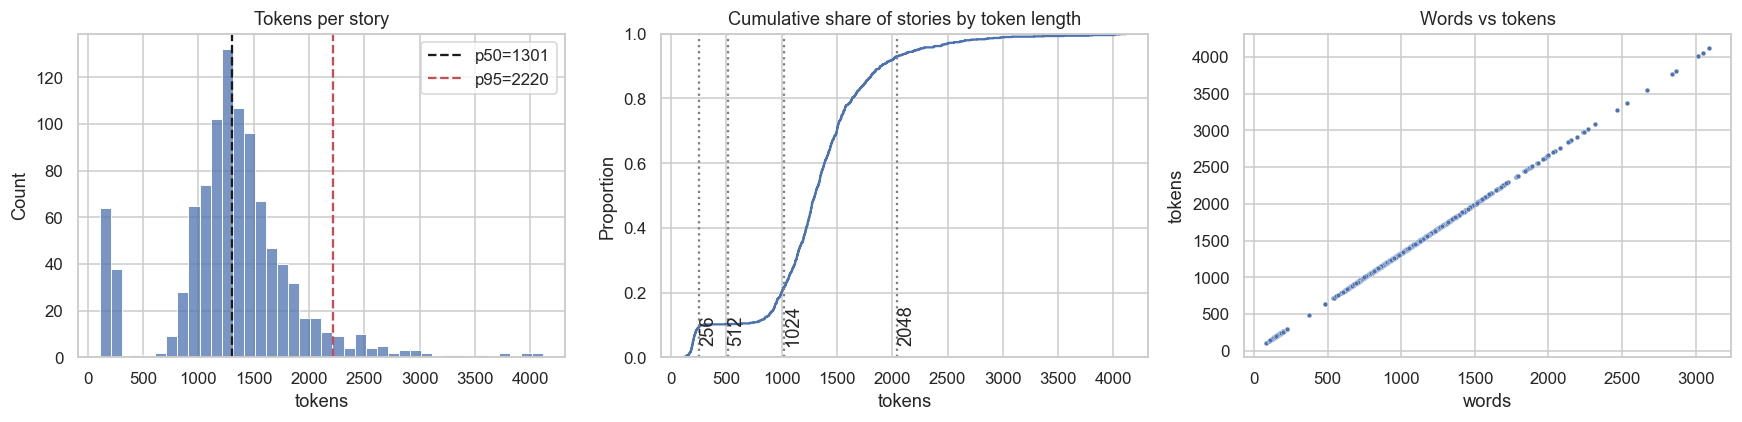

,128,256,384,512,1024,2048,4096
% stories that fit whole,0.1,9.5,10.2,10.3,21.7,93.1,99.9


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df.tokens, bins=40, ax=axes[0], color="#4C72B0")
for q, c in [(.5, "k"), (.95, "r")]:
    axes[0].axvline(df.tokens.quantile(q), color=c, ls="--", label=f"p{int(q*100)}={int(df.tokens.quantile(q))}")
axes[0].legend(); axes[0].set_title("Tokens per story")
sns.ecdfplot(df.tokens, ax=axes[1]); axes[1].set_title("Cumulative share of stories by token length")
for lim in (256, 512, 1024, 2048):
    axes[1].axvline(lim, color="grey", ls=":"); axes[1].text(lim, .05, str(lim), rotation=90)
sns.scatterplot(x=df.words, y=df.tokens, s=10, ax=axes[2]); axes[2].set_title("Words vs tokens")
plt.tight_layout(); plt.show()

fits = {lim: round(100 * (df.tokens <= lim).mean(), 1) for lim in (128, 256, 384, 512, 1024, 2048, 4096)}
display(pd.Series(fits, name="% stories that fit whole").to_frame().T)
FINDINGS["fits_512_pct"], FINDINGS["fits_1024_pct"] = fits[512], fits[1024]

In [11]:
# Chunk budget for retrieval: how many chunks per story and in total, at common sizes/overlaps.
def n_chunks(n, size, overlap):
    return 1 if n <= size else 1 + math.ceil((n - size) / (size - overlap))

rows = []
for size, ov in [(128, 32), (256, 32), (256, 64), (384, 64), (512, 64), (512, 128)]:
    c = df.tokens.map(lambda n: n_chunks(n, size, ov))
    rows.append(dict(chunk_tokens=size, overlap=ov, total_chunks=int(c.sum()),
                     mean_per_story=round(c.mean(), 2), max_per_story=int(c.max()),
                     pct_single_chunk=round(100 * (c == 1).mean(), 1)))
chunk_tbl = pd.DataFrame(rows); display(chunk_tbl)
FINDINGS["chunks_256_32"] = int(chunk_tbl.query("chunk_tokens==256 and overlap==32").total_chunks.iloc[0])

# Index size for embeddings (float32) at typical dims - relevant for CPU deployment (Task 3).
for dim in (384, 768, 1024):
    mb = FINDINGS["chunks_256_32"] * dim * 4 / 1e6
    print(f"embedding index @ {dim}-d, 256/32 chunks: {mb:.1f} MB (float32)")

# Context needed to answer from top-k whole stories vs chunks
for k in (1, 3, 5):
    print(f"top-{k} whole stories, p95 prompt ~ {k*FINDINGS['tokens_p95']} tokens | top-{k} 256-token chunks ~ {k*256}")

,chunk_tokens,overlap,total_chunks,mean_per_story,max_per_story,pct_single_chunk
0,128,32,13811,13.81,43,0.1
1,256,32,6182,6.18,19,9.5
2,256,64,6989,6.99,22,9.5
3,384,64,4403,4.40,13,10.2
4,512,64,3289,3.29,10,10.3
5,512,128,3614,3.61,11,10.3


embedding index @ 384-d, 256/32 chunks: 9.5 MB (float32)
embedding index @ 768-d, 256/32 chunks: 19.0 MB (float32)
embedding index @ 1024-d, 256/32 chunks: 25.3 MB (float32)
top-1 whole stories, p95 prompt ~ 2220 tokens | top-1 256-token chunks ~ 256
top-3 whole stories, p95 prompt ~ 6660 tokens | top-3 256-token chunks ~ 768
top-5 whole stories, p95 prompt ~ 11100 tokens | top-5 256-token chunks ~ 1280


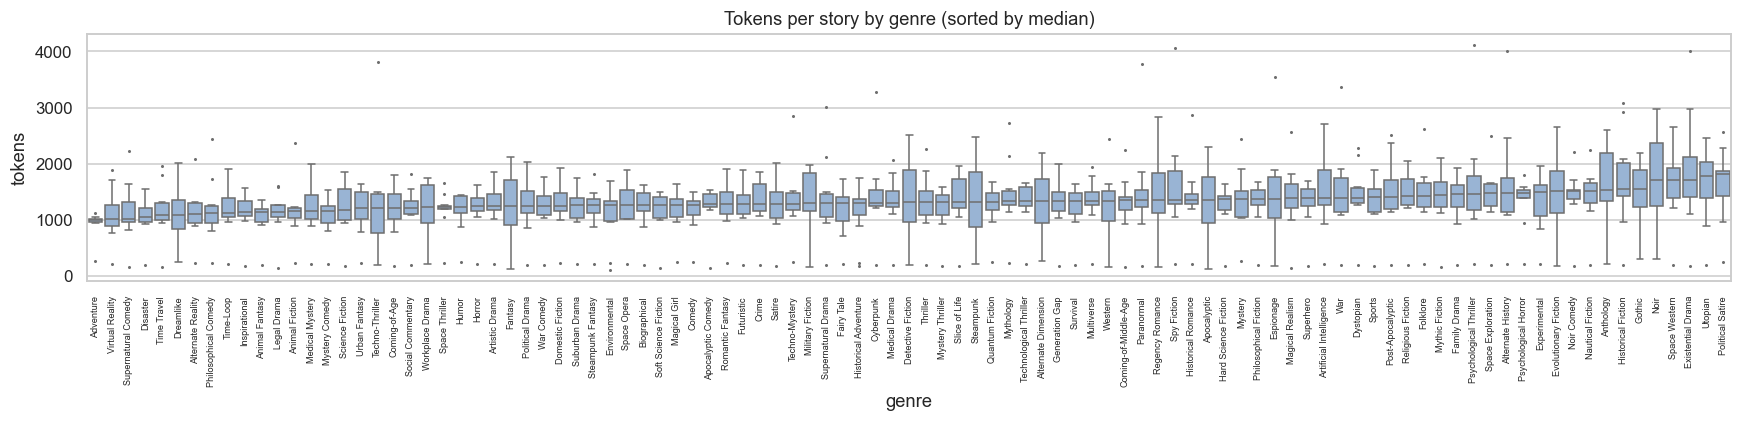

Kruskal-Wallis on tokens across genres: H=115.5, p=0.11 -> no evidence length differs by genre


,median tokens
genre,
Adventure,991.0
Virtual Reality,1022.0
Supernatural Comedy,1023.0
Existential Drama,1713.5
Utopian,1780.0
Political Satire,1809.5


In [12]:
# Length by genre: does length leak genre? (a shortcut the classifier could learn)
order = df.groupby("genre").tokens.median().sort_values().index
fig, ax = plt.subplots(figsize=(16, 4))
sns.boxplot(data=df, x="genre", y="tokens", order=order, ax=ax, fliersize=1, color="#8FB3DE")
ax.tick_params(axis="x", rotation=90, labelsize=6); ax.set_title("Tokens per story by genre (sorted by median)")
plt.tight_layout(); plt.show()

from scipy.stats import kruskal
H, pval = kruskal(*[grp.tokens.values for _, grp in df.groupby("genre")])
FINDINGS["length_genre_kruskal_p"] = float(pval)
print(f"Kruskal-Wallis on tokens across genres: H={H:.1f}, p={pval:.3g}",
      "-> length differs by genre" if pval < .05 else "-> no evidence length differs by genre")
display(df.groupby("genre").tokens.median().sort_values().iloc[[0,1,2,-3,-2,-1]].to_frame("median tokens"))

## 5. Text quality and duplicates

In [13]:
q = pd.DataFrame({
    "non_ascii_chars": s.map(lambda x: sum(ord(ch) > 127 for ch in x)),
    "has_html": s.str.contains(r"<[a-zA-Z/][^>]*>"),
    "has_url": s.str.contains(r"https?://|www\\."),
    "has_markdown": s.str.contains(r"(^|\n)#{1,6} |\*\*"),
    "starts_with_title": [norm(b).startswith(norm(a)) for a, b in zip(t, s)],
    "leading/trailing ws": s.ne(s.str.strip()),
    "ascii_letter_ratio": s.map(lambda x: sum(ch in string.ascii_letters for ch in x) / max(1, sum(ch.isalpha() for ch in x))),
})
summary = pd.Series({
    "stories with any non-ASCII char": int((q.non_ascii_chars > 0).sum()),
    "stories with HTML tags": int(q.has_html.sum()),
    "stories with URLs": int(q.has_url.sum()),
    "stories with markdown": int(q.has_markdown.sum()),
    "stories that start with their title": int(q.starts_with_title.sum()),
    "stories with leading/trailing whitespace": int(q["leading/trailing ws"].sum()),
    "stories likely not English (ascii letter ratio < 0.9)": int((q.ascii_letter_ratio < .9).sum()),
    "very short stories (< 50 words)": int((df.words < 50).sum()),
})
display(summary.to_frame("count"))
FINDINGS["quality_flags"] = {k: v for k, v in summary.items() if v}
print("Most frequent non-ASCII characters:", collections.Counter(ch for x in s for ch in x if ord(ch) > 127).most_common(10))

,count
stories with any non-ASCII char,48
stories with HTML tags,0
stories with URLs,0
stories with markdown,0
stories that start with their title,1
stories with leading/trailing whitespace,5
stories likely not English (ascii letter ratio < 0.9),0
very short stories (< 50 words),0


Most frequent non-ASCII characters: [('é', 80), ('–', 17), ('ü', 8), ('ū', 4), ('ö', 3), ('É', 2), ('ç', 2), ('ê', 1), ('—', 1), ('…', 1)]


exact duplicate stories (normalized): 0
near-duplicate pairs (cosine > 0.8): 0 | > 0.5: 0


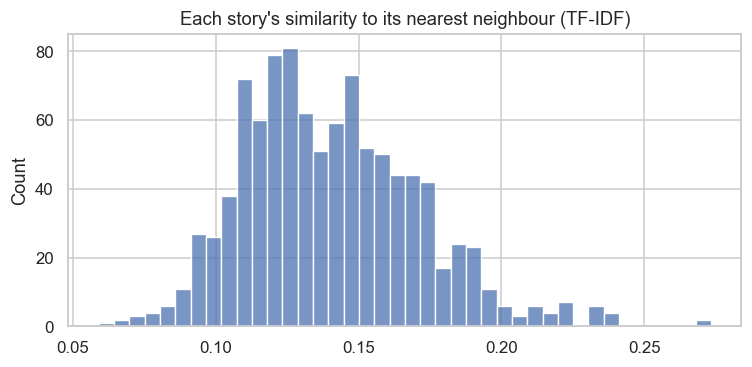

,sim,title_a,genre_a,title_b,genre_b
0,0.273,The Unlikely Champion,Sports,The Final Pitch,Sports
1,0.241,The Enigmatic Gaze,Medical Mystery,The Enigma of the Emerald Eye,Medical Mystery
2,0.239,Heartstrings,Medical Drama,The Heart of a Champion,Medical Drama
3,0.236,Dr. Gray's Enigmatic Puzzle,Medical Mystery,The Enigma of Dr. Gray,Medical Mystery
4,0.235,Champion's Unlikely Journey,Sports,Spirit's Resilient Flame,Sports
5,0.232,The Last Bench,Legal Drama,The Final Verdict,Legal Drama
6,0.224,Heartbeat's Uncharted Distance,Medical Drama,Heartstrings,Medical Drama
7,0.224,The Enchanting Duchess,Regency Romance,The Dukes Dilemma,Regency Romance
8,0.223,The Generation Gap: A Tale of Two Worlds,Generation Gap,Bridging the Divide: A Tale of the Generation Gap,Generation Gap
9,0.220,The Case of the Missing Masterpiece,Mystery Comedy,The Mystery of the Misplaced Masterpiece,Mystery Comedy


In [14]:
# Exact and near-duplicate stories (TF-IDF cosine). Near-dupes across genres = label noise;
# near-dupes across train/test = leakage for the classifier.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

FINDINGS["story_exact_dupes"] = int(s.map(norm).duplicated(keep=False).sum())
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, stop_words="english", ngram_range=(1, 2))
X = tfidf.fit_transform(s)
S = cosine_similarity(X); np.fill_diagonal(S, 0)
nn_sim = S.max(1)
FINDINGS["near_dupe_pairs_0.8"] = int((np.triu(S) > .8).sum())
print("exact duplicate stories (normalized):", FINDINGS["story_exact_dupes"])
print("near-duplicate pairs (cosine > 0.8):", FINDINGS["near_dupe_pairs_0.8"], "| > 0.5:", int((np.triu(S) > .5).sum()))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(nn_sim, bins=40, ax=ax); ax.set_title("Each story's similarity to its nearest neighbour (TF-IDF)")
plt.tight_layout(); plt.show()

i, j = np.unravel_index(np.argsort(-np.triu(S), axis=None)[:10], S.shape)
display(pd.DataFrame({"sim": S[i, j].round(3), "title_a": t.values[i], "genre_a": g.values[i],
                      "title_b": t.values[j], "genre_b": g.values[j]}))

## 6. Vocabulary and genre-specific language

In [15]:
words_all = [w for x in s for w in tok(x)]
vc = collections.Counter(words_all)
FINDINGS["vocab_size"] = len(vc)
print(f"total words: {len(words_all):,} | vocabulary: {len(vc):,} | hapax (seen once): {sum(v==1 for v in vc.values()):,}")
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
content = [(w, c) for w, c in vc.most_common(200) if w not in ENGLISH_STOP_WORDS and len(w) > 2][:25]
display(pd.DataFrame(content, columns=["word", "count"]).T)

# Cliche check: very frequent phrases hint at templated LLM-generated text, which makes stories look alike.
try:
    bi = TfidfVectorizer(ngram_range=(3, 4), min_df=10, use_idf=False, norm=None).fit(s)
    df_counts = (bi.transform(s) > 0).sum(0).A1
    top_phr = sorted(zip(bi.get_feature_names_out(), df_counts), key=lambda x: -x[1])[:15]
    display(pd.DataFrame(top_phr, columns=["phrase (3-4 gram)", "stories containing it"]))
except ValueError:
    print("No 3-4 word phrase appears in 10+ stories: little templated phrasing.")

total words: 987,426 | vocabulary: 18,078 | hapax (seen once): 4,604


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
word,world,power,began,new,city,life,time,heart,town,knew,...,story,battle,team,heroes,jack,day,man,ancient,thomas,chapter
count,3352,3258,2308,1883,1865,1763,1728,1713,1646,1640,...,1464,1401,1362,1359,1341,1337,1330,1322,1253,1242


,phrase (3-4 gram),stories containing it
0,the power of,629
1,the heart of,548
2,testament to the,469
3,and so the,462
4,deeper into the,427
5,known as the,421
6,heart of the,413
7,the story of,406
8,the heart of the,401
9,in the end,391


In [16]:
# Most distinctive terms per genre (mean TF-IDF within genre minus overall mean)
terms = np.array(tfidf.get_feature_names_out())
overall = np.asarray(X.mean(0)).ravel()
rows = []
for gen in counts.index:
    m = np.asarray(X[(g == gen).values].mean(0)).ravel() - overall
    rows.append((gen, ", ".join(terms[np.argsort(-m)[:8]])))
distinct = pd.DataFrame(rows, columns=["genre", "top distinctive terms"])
display(distinct.head(100))

,genre,top distinctive terms
0,Historical Adventure,"kingdom, scepter, golden, compass, golden compass, sword, reginald, adventure"
1,Science Fiction,"galaxy, earth, dr, cosmos, galactic, planet, crew, new earth"
2,Alternate Dimension,"dimension, portal, dimensions, realm, alternate, reality, shadow, realms"
3,Romantic Fantasy,"enchanted, enchanted forest, forest, kingdom, magical, love, enchanted garden, aldric"
4,Technological Thriller,"ai, dr, project, technological, neurolink, project genesis, global, potential"
...,...,...
94,Apocalyptic,"survivors, earth, sunrise, humanity, wasteland, apocalypse, solar, barren"
95,Space Opera,"crew, galaxy, federation, starship, planet, captain, galactic, voyager"
96,Family Drama,"family, emily, school, john, town, parents, sarah, tommy"
97,Coming-of-Age,"lily, boy, adventure, summer, young boy, tim, boy named, ethan"


## 7. How separable are the genres? (Task 2 baseline)

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

n_splits = int(min(5, counts.min()))
FINDINGS["cv_folds"] = n_splits
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RNG)
y = g.to_numpy(dtype=object)
models = {
    "TF-IDF + LinearSVC": make_pipeline(TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), stop_words="english"), LinearSVC(C=0.5)),
    "TF-IDF + LogReg": make_pipeline(TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), stop_words="english"), LogisticRegression(C=10, max_iter=2000)),
    "Title only + LinearSVC": None,
}
res, preds = [], {}
for name, m in models.items():
    if m is None:
        m = make_pipeline(TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4)), LinearSVC())
        yp = cross_val_predict(m, t.to_numpy(dtype=object), y, cv=skf)
    else:
        yp = cross_val_predict(m, s.to_numpy(dtype=object), y, cv=skf)
    preds[name] = yp
    res.append(dict(model=name, accuracy=accuracy_score(y, yp), macro_f1=f1_score(y, yp, average="macro")))
res = pd.DataFrame(res).round(3); display(res)
print(f"chance accuracy = {1/counts.size:.3f} | majority class = {counts.max()/len(df):.3f} | {n_splits}-fold stratified CV")
best = res.sort_values("macro_f1").iloc[-1]
FINDINGS["baseline_model"], FINDINGS["baseline_acc"], FINDINGS["baseline_f1"] = best.model, best.accuracy, best.macro_f1
FINDINGS["title_only_acc"] = float(res.set_index("model").loc["Title only + LinearSVC", "accuracy"])

,model,accuracy,macro_f1
0,TF-IDF + LinearSVC,0.598,0.566
1,TF-IDF + LogReg,0.595,0.584
2,Title only + LinearSVC,0.370,0.357


chance accuracy = 0.010 | majority class = 0.020 | 5-fold stratified CV


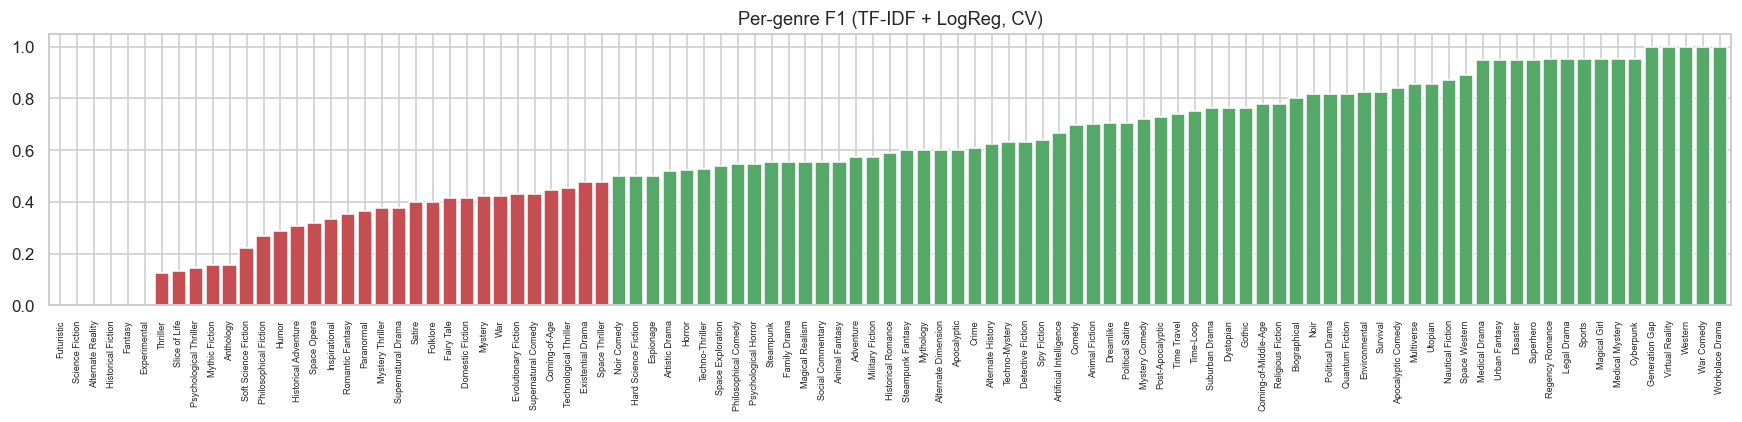

Hardest genres:


,precision,recall,f1-score,support
Futuristic,0.00,0.0,0.00,10.0
Science Fiction,0.00,0.0,0.00,10.0
Alternate Reality,0.00,0.0,0.00,10.0
Historical Fiction,0.00,0.0,0.00,10.0
Fantasy,0.00,0.0,0.00,10.0
Experimental,0.00,0.0,0.00,10.0
Thriller,0.17,0.1,0.12,10.0
Slice of Life,0.20,0.1,0.13,10.0
Psychological Thriller,0.25,0.1,0.14,10.0
Mythic Fiction,0.33,0.1,0.15,10.0


Easiest genres:


,precision,recall,f1-score,support
Generation Gap,1.0,1.0,1.0,10.0
Virtual Reality,1.0,1.0,1.0,10.0
Western,1.0,1.0,1.0,10.0
War Comedy,1.0,1.0,1.0,10.0
Workplace Drama,1.0,1.0,1.0,10.0


In [18]:
yp = preds[FINDINGS["baseline_model"]]
rep = pd.DataFrame(classification_report(y, yp, output_dict=True, zero_division=0)).T.iloc[:-3]
rep = rep.sort_values("f1-score")
fig, ax = plt.subplots(figsize=(16, 4))
rep["f1-score"].plot.bar(ax=ax, color=np.where(rep["f1-score"] < .5, "#C44E52", "#55A868"), width=.85)
ax.set_title(f"Per-genre F1 ({FINDINGS['baseline_model']}, CV)"); ax.tick_params(axis="x", labelsize=6)
plt.tight_layout(); plt.show()
print("Hardest genres:"); display(rep.head(10).round(2))
print("Easiest genres:"); display(rep.tail(5).round(2))
FINDINGS["hardest_genres"] = rep.head(5).index.tolist()
FINDINGS["genres_f1_below_0.5"] = int((rep["f1-score"] < .5).sum())

,genre_a,genre_b,confusions
0,Historical Adventure,Historical Fiction,9
1,Military Fiction,War,9
2,Spy Fiction,Espionage,7
3,Philosophical Fiction,Philosophical Comedy,6
4,Domestic Fiction,Family Drama,6
5,Historical Adventure,Mythic Fiction,6
6,Space Thriller,Space Opera,6
7,Steampunk Fantasy,Steampunk,6
8,Space Exploration,Space Opera,5
9,Historical Adventure,Fantasy,5


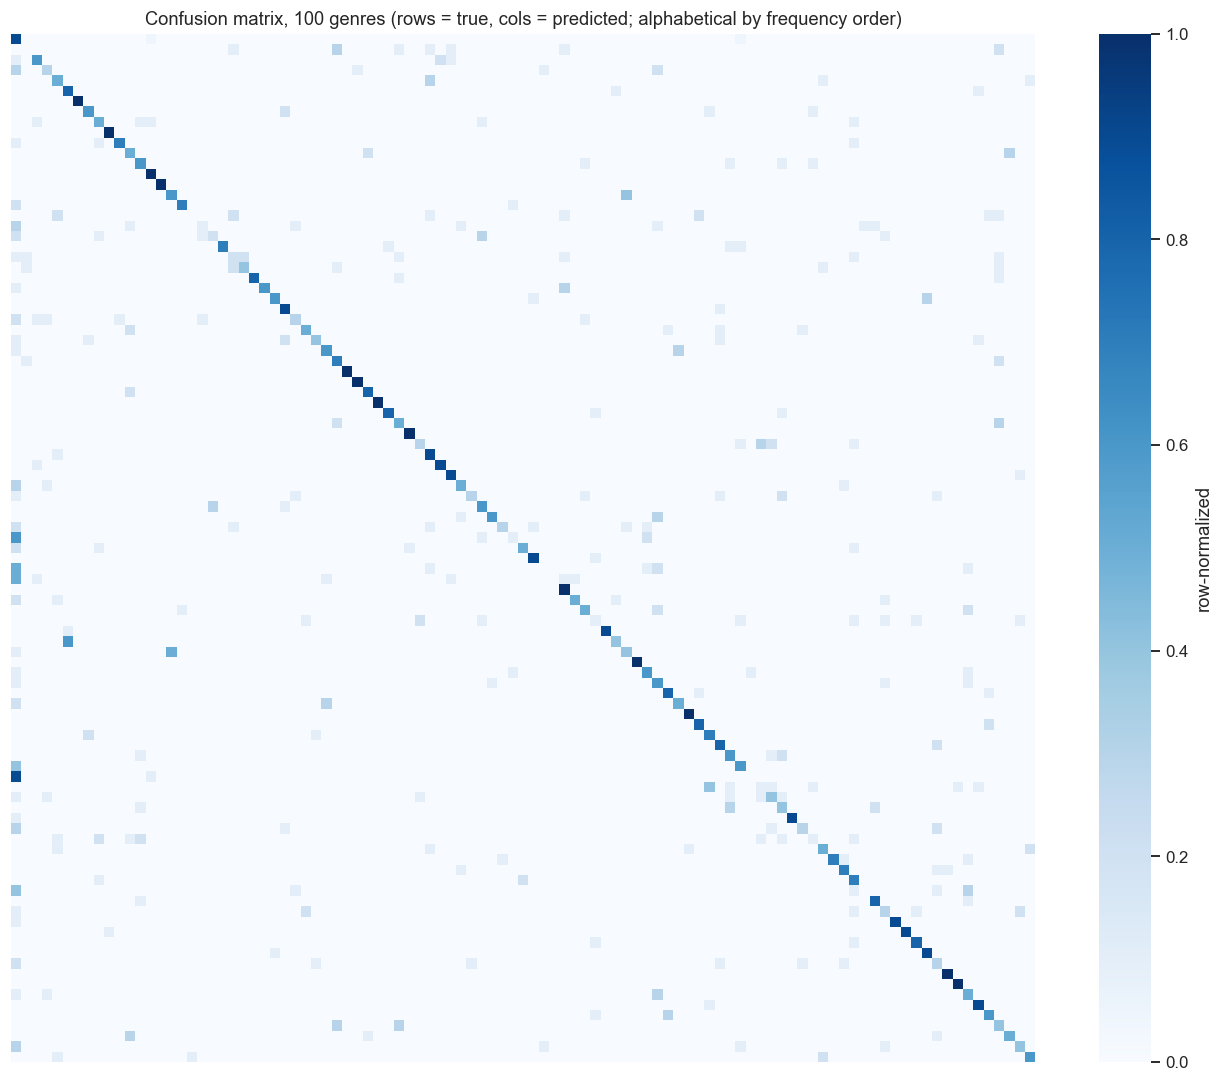

In [19]:
# Most confused genre pairs (off-diagonal of the confusion matrix, symmetrized)
labels = list(counts.index)
cm = confusion_matrix(y, yp, labels=labels)
off = cm + cm.T; np.fill_diagonal(off, 0)
iu = np.triu_indices_from(off, 1)
top = np.argsort(-off[iu])[:15]
conf_pairs = pd.DataFrame({"genre_a": np.array(labels)[iu[0][top]], "genre_b": np.array(labels)[iu[1][top]],
                           "confusions": off[iu][top]})
conf_pairs = conf_pairs[conf_pairs.confusions > 0]
display(conf_pairs)
FINDINGS["top_confusions"] = [f"{a} / {b}" for a, b in conf_pairs[["genre_a", "genre_b"]].values[:5]] or ["none"]

fig, ax = plt.subplots(figsize=(12, 10))
cmn = cm / cm.sum(1, keepdims=True)
sns.heatmap(cmn, cmap="Blues", xticklabels=False, yticklabels=False, ax=ax, cbar_kws={"label": "row-normalized"})
ax.set_title("Confusion matrix, 100 genres (rows = true, cols = predicted; alphabetical by frequency order)")
plt.tight_layout(); plt.show()

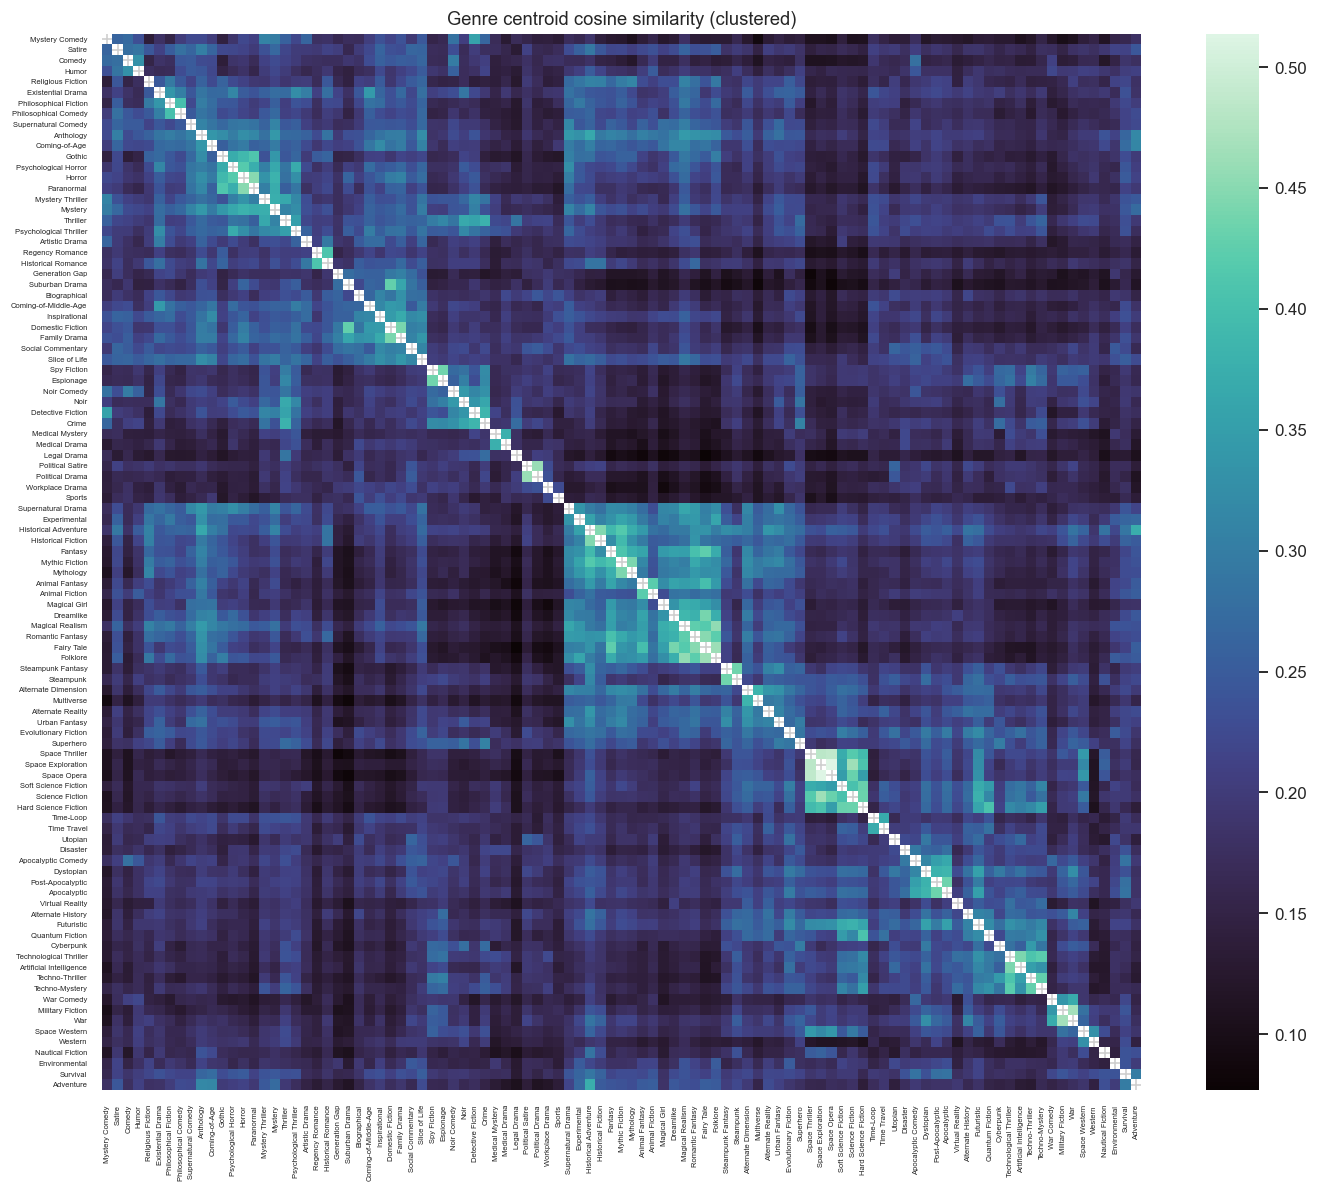

,genre_a,genre_b,centroid_cosine
0,Space Exploration,Space Opera,0.514
1,Space Thriller,Space Opera,0.487
2,Space Exploration,Space Thriller,0.483
3,Military Fiction,War,0.467
4,Science Fiction,Space Exploration,0.464
5,Fairy Tale,Folklore,0.462
6,Political Satire,Political Drama,0.461
7,Magical Realism,Folklore,0.455
8,Romantic Fantasy,Fairy Tale,0.449
9,Horror,Paranormal,0.449


mean story-story cosine within genre 0.0815 vs across genres 0.0338


In [20]:
# Genre centroid similarity: which genres live in the same region of TF-IDF space
cent = np.vstack([np.asarray(X[(g == gen).values].mean(0)).ravel() for gen in labels])
CS = cosine_similarity(cent); np.fill_diagonal(CS, np.nan)
import scipy.cluster.hierarchy as sch
Z = sch.linkage(1 - np.nan_to_num(CS, nan=1), method="average")
ordr = sch.leaves_list(Z)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(CS[np.ix_(ordr, ordr)], cmap="mako", xticklabels=np.array(labels)[ordr], yticklabels=np.array(labels)[ordr], ax=ax)
ax.tick_params(labelsize=5); ax.set_title("Genre centroid cosine similarity (clustered)")
plt.tight_layout(); plt.show()
k = np.dstack(np.unravel_index(np.argsort(-np.nan_to_num(np.triu(CS, 1), nan=0), axis=None)[:10], CS.shape))[0]
display(pd.DataFrame([(labels[a], labels[b], round(CS[a, b], 3)) for a, b in k], columns=["genre_a", "genre_b", "centroid_cosine"]))

# intra- vs inter-genre similarity: a single-number separability indicator
same = (y[:, None] == y[None, :]); np.fill_diagonal(same, False)
diff = ~same; np.fill_diagonal(diff, False)
FINDINGS["intra_sim"], FINDINGS["inter_sim"] = round(S[same].mean(), 4), round(S[diff].mean(), 4)
print(f"mean story-story cosine within genre {FINDINGS['intra_sim']} vs across genres {FINDINGS['inter_sim']}")

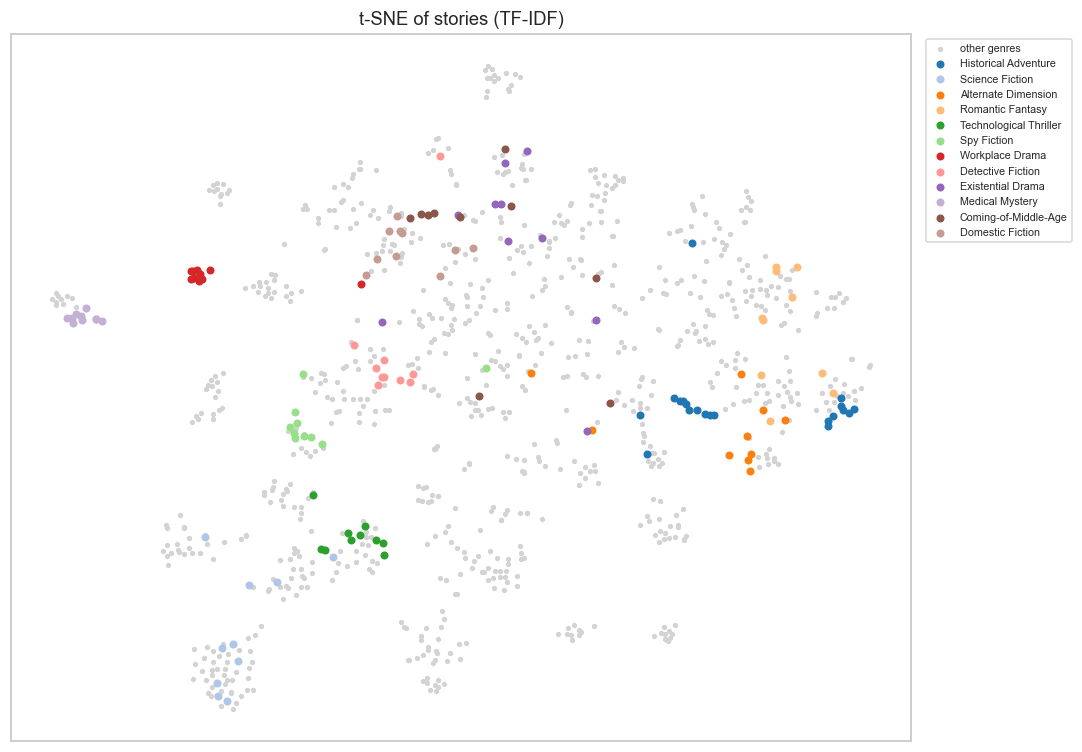

In [21]:
# 2-D map of stories (TF-IDF -> SVD 50 -> t-SNE), top 12 genres highlighted
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
Z50 = TruncatedSVD(50, random_state=RNG).fit_transform(X)
emb = TSNE(2, perplexity=30, init="pca", random_state=RNG).fit_transform(Z50)
top12 = counts.index[:12]
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(*emb[~g.isin(top12)].T, s=6, c="lightgrey", label="other genres")
pal = sns.color_palette("tab20", 12)
for c, gen in zip(pal, top12):
    msk = (g == gen).values; ax.scatter(*emb[msk].T, s=18, color=c, label=gen)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left"); ax.set_title("t-SNE of stories (TF-IDF)")
ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout(); plt.show()

## 8. Retrieval sanity checks (Task 1 baseline)

In [22]:
# Can a plain lexical retriever find a story from (a) its title, (b) its first sentence, (c) its genre?
def recall_at(queries, k=(1, 5, 10)):
    Q = tfidf.transform(queries); sims = cosine_similarity(Q, X)
    rank = (sims > sims[np.arange(len(df)), np.arange(len(df))][:, None]).sum(1)  # 0 = top
    return {f"R@{kk}": round((rank < kk).mean(), 3) for kk in k} | {"MRR": round((1 / (rank + 1)).mean(), 3)}

first_sent = s.str.split(r"(?<=[.!?])\s+", n=1, regex=True).str[0]
# a 'paraphrase-like' query: 8 random content words from the story's middle
rng = np.random.default_rng(RNG)
def mid_words(x):
    w = [w for w in tok(x) if w not in ENGLISH_STOP_WORDS and len(w) > 3]
    w = w[len(w)//3: 2*len(w)//3] or w
    return " ".join(rng.choice(w, size=min(8, len(w)), replace=False))
retr = pd.DataFrame({
    "title as query": recall_at(t),
    "first sentence as query": recall_at(first_sent),
    "8 content words from the middle": recall_at(s.map(mid_words)),
}).T
display(retr)
FINDINGS["title_R@1"] = retr.loc["title as query", "R@1"]
FINDINGS["keywords_R@5"] = retr.loc["8 content words from the middle", "R@5"]

,R@1,R@5,R@10,MRR
title as query,0.441,0.721,0.781,0.566
first sentence as query,0.940,0.994,0.996,0.965
8 content words from the middle,0.919,0.994,1.000,0.952


In [23]:
# Genre queries: does the genre name itself retrieve stories of that genre? (tests whether genre words appear in text)
gq = cosine_similarity(tfidf.transform(list(counts.index)), X)
prec10 = np.mean([(g.values[np.argsort(-gq[i])[:10]] == gen).mean() for i, gen in enumerate(counts.index)])
mention = np.mean([norm(a) in norm(b) for a, b in zip(g, s)])
FINDINGS["genre_P@10"], FINDINGS["genre_in_story_pct"] = round(prec10, 3), round(100 * mention, 1)
print(f"precision@10 when querying with the genre name: {prec10:.3f}")
print(f"stories that mention their own genre name verbatim: {100*mention:.1f}%")

precision@10 when querying with the genre name: 0.279
stories that mention their own genre name verbatim: 25.3%


## 9. Split plan for Task 2

In [24]:
# With few examples per genre, the split size matters a lot. Show per-genre test counts for common schemes.
for test_frac in (0.1, 0.2, 0.3):
    per = (counts * test_frac).round().astype(int)
    print(f"test={int(test_frac*100)}%: test stories per genre min={per.min()} max={per.max()} | train per genre min={(counts-per).min()}")
FINDINGS["min_per_genre"] = int(counts.min())

test=10%: test stories per genre min=1 max=2 | train per genre min=9
test=20%: test stories per genre min=2 max=4 | train per genre min=8
test=30%: test stories per genre min=3 max=6 | train per genre min=7


## 10. Key findings

In [25]:
F = FINDINGS
lines = [
 f"**Size**: {F['n_rows']:,} stories, {F['n_genres']} genres, {F['missing_cells']} missing/empty cells.",
 f"**Ids**: unique = {F['ids_unique']} ({F['id_dupes']} duplicates), format {F['id_format']}. Exact id lookup is safe" + ("." if F['ids_unique'] else " only after de-duplication."),
 f"**Genres**: {F['per_genre_min']}-{F['per_genre_max']} stories each (imbalance {F['imbalance_ratio']}x, normalized entropy {F['norm_entropy']}); {F['genre_name_collisions']} genre-name collisions after normalization. Only ~{F['min_per_genre']} examples per class, so use stratified CV and report macro-F1.",
 f"**Titles**: {F['unique_titles']:,} unique; {F['title_norm_dupes']} rows share a (normalized) title, {F['dup_titles_cross_genre']} such titles span several genres. Title lookup must handle multiple matches (return a list or disambiguate by genre/id). Title appears in story text {F['title_in_story_pct']}% of the time.",
 f"**Length** ({F['tok_note']}): median {F['tokens_median']} tokens, p95 {F['tokens_p95']}, max {F['tokens_max']}; corpus ~{F['tokens_total']:,} tokens. {F['fits_512_pct']}% of stories fit in 512 tokens and {F['fits_1024_pct']}% in 1,024.",
 f"**Chunking**: 256-token chunks with 32 overlap give {F['chunks_256_32']:,} chunks, a tiny index (a few MB) that is trivially CPU-friendly for Task 3.",
 f"**Length vs genre**: Kruskal-Wallis p = {F['length_genre_kruskal_p']:.3g}" + (" (length carries some genre signal)." if F['length_genre_kruskal_p'] < .05 else " (length is not a genre cue)."),
 f"**Duplicates**: {F['story_exact_dupes']} exact duplicate stories, {F['near_dupe_pairs_0.8']} near-duplicate pairs (TF-IDF cosine > 0.8).",
 f"**Separability**: best lexical baseline ({F['baseline_model']}, {F['cv_folds']}-fold CV) reaches accuracy {F['baseline_acc']:.3f}, macro-F1 {F['baseline_f1']:.3f} vs chance {1/F['n_genres']:.3f}; title-only accuracy {F['title_only_acc']:.3f}. {F['genres_f1_below_0.5']} genres have F1 < 0.5. Within-genre similarity {F['intra_sim']} vs across {F['inter_sim']}.",
 f"**Hardest genres**: {', '.join(F['hardest_genres'])}. **Most confused pairs**: {'; '.join(F['top_confusions'])}.",
 f"**Retrieval baseline**: TF-IDF finds a story from its title at R@1 = {F['title_R@1']}, from 8 keywords at R@5 = {F['keywords_R@5']}. Querying by genre name gives P@10 = {F['genre_P@10']}; only {F['genre_in_story_pct']}% of stories name their genre, so genre questions should use the metadata filter, not semantic search.",
 f"**Quality flags**: {F['quality_flags'] or 'none'}.",
]
display(Markdown("\n".join(f"- {l}" for l in lines)))

- **Size**: 1,000 stories, 99 genres, 0 missing/empty cells.
- **Ids**: unique = True (0 duplicates), format numeric 1328-998783. Exact id lookup is safe.
- **Genres**: 10-20 stories each (imbalance 2.0x, normalized entropy 0.9992); 0 genre-name collisions after normalization. Only ~10 examples per class, so use stratified CV and report macro-F1.
- **Titles**: 1,000 unique; 6 rows share a (normalized) title, 0 such titles span several genres. Title lookup must handle multiple matches (return a list or disambiguate by genre/id). Title appears in story text 40.8% of the time.
- **Length** (estimate (words x 1.33); tokenizer unavailable: OSError): median 1301 tokens, p95 2220, max 4114; corpus ~1,311,179 tokens. 10.3% of stories fit in 512 tokens and 21.7% in 1,024.
- **Chunking**: 256-token chunks with 32 overlap give 6,182 chunks, a tiny index (a few MB) that is trivially CPU-friendly for Task 3.
- **Length vs genre**: Kruskal-Wallis p = 0.11 (length is not a genre cue).
- **Duplicates**: 0 exact duplicate stories, 0 near-duplicate pairs (TF-IDF cosine > 0.8).
- **Separability**: best lexical baseline (TF-IDF + LogReg, 5-fold CV) reaches accuracy 0.595, macro-F1 0.584 vs chance 0.010; title-only accuracy 0.370. 33 genres have F1 < 0.5. Within-genre similarity 0.0815 vs across 0.0338.
- **Hardest genres**: Futuristic, Science Fiction, Alternate Reality, Historical Fiction, Fantasy. **Most confused pairs**: Historical Adventure / Historical Fiction; Military Fiction / War; Spy Fiction / Espionage; Philosophical Fiction / Philosophical Comedy; Domestic Fiction / Family Drama.
- **Retrieval baseline**: TF-IDF finds a story from its title at R@1 = 0.441, from 8 keywords at R@5 = 0.994. Querying by genre name gives P@10 = 0.279; only 25.3% of stories name their genre, so genre questions should use the metadata filter, not semantic search.
- **Quality flags**: {'stories with any non-ASCII char': 48, 'stories that start with their title': 1, 'stories with leading/trailing whitespace': 5}.

### What this means for the build

- **Task 1 (chatbot):** route exact questions (id, title, genre) to a metadata lookup and meaning-based questions to embedding search. Stories are short enough that retrieving whole stories (or 1 to 2 chunks each) keeps prompts small, so a small instruct model with a 4k context is enough. Title lookups must allow several matches.
- **Task 2 (classifier):** with about 10 stories per genre, full fine-tuning would overfit; a LoRA adapter or a head on frozen embeddings, with stratified CV and macro-F1, is the right setup. The lexical baseline above is the bar to beat, and the confused pairs show where errors will concentrate. Keeping the adapter switchable leaves the chatbot's base weights untouched.
- **Task 3 (CPU):** the whole corpus and index fit in memory easily; latency will be dominated by LLM generation, not retrieval, so effort belongs in model quantization and short prompts.

In [66]:
print(type(df.sample(10)['story'].values))
# print(list(df.sample(10)['story'].values))
[print(f'{x}') for x in list(df.sample(1)['story'].values)]

<class 'numpy.ndarray'>
Once upon a time, in a small, picturesque town nestled in the heart of the lush green countryside, there lived a young man named Jack. Jack was a tall, athletic, and ambitious individual who possessed an unmatched passion for the sport of cricket. Since his childhood, he had spent countless hours practicing and honing his skills on the cricket field. Jack's dream was to one day become a renowned cricketer, representing his country on the international stage.

The townspeople adored Jack and his undeniable talent, and they all eagerly awaited the day when he would make it big in the world of sports. They often gathered around the local cricket ground to watch Jack practice, cheering him on and sharing his dreams of success. Jack's father, a former cricketer himself, was his biggest supporter and mentor. He had always believed that with hard work, dedication, and unwavering belief in oneself, anything was possible.

One day, Jack received the news he had been wait

[None]